# 📦 Demand Forecast Regression — ML Project
## Dataset : Product Demand Forecasting (Kaggle)
## Models  : Linear Regression | Random Forest | Gradient Boosting

## Cell 1 : Import Libraries

In [1]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


## Cell 2 : Load Dataset
> Download Historical Product Demand.csv from Kaggle and place in same folder

In [2]:
# Read the CSV file
df = pd.read_csv("Historical Product Demand.csv")
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


## Cell 3 : EDA

In [3]:
# Check shape
print("Shape:", df.shape)

# Check column names
print("Columns:", df.columns.tolist())

Shape: (1048575, 5)
Columns: ['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


In [6]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 122423


In [7]:
# Basic statistics
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


## Cell 4 : Clean Data

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove brackets like (100) from Order_Demand column
df["Order_Demand"] = df["Order_Demand"].astype(str)
df["Order_Demand"] = df["Order_Demand"].str.replace("(", "", regex=False)
df["Order_Demand"] = df["Order_Demand"].str.replace(")", "", regex=False)

# Convert to numbers
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

# Remove rows where demand is 0 or negative
df = df[df["Order_Demand"] > 0]

# Remove missing values
df = df.dropna()
df = df.reset_index(drop=True)

print("Data cleaned! Shape now:", df.shape)

Data cleaned! Shape now: (904633, 5)


## Cell 5 : Feature Engineering

In [9]:
# Label Encode text columns — ML models only understand numbers!
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Warehouse_Encoded"] = le.fit_transform(df["Warehouse"])
df["Category_Encoded"]  = le.fit_transform(df["Product_Category"])
df["Product_Encoded"]   = le.fit_transform(df["Product_Code"])

print("Encoding done!")
df[["Warehouse", "Warehouse_Encoded",
    "Product_Category", "Category_Encoded",
    "Product_Code", "Product_Encoded"]].head()

Encoding done!


,Warehouse,Warehouse_Encoded,Product_Category,Category_Encoded,Product_Code,Product_Encoded
0,Whse_J,2,Category_028,27,Product_0993,982
1,Whse_J,2,Category_028,27,Product_0979,968
2,Whse_J,2,Category_028,27,Product_0979,968
3,Whse_J,2,Category_028,27,Product_0979,968
4,Whse_J,2,Category_028,27,Product_0979,968


In [10]:
# Convert Date to number — ML models cannot read dates directly!
df["Date_Encoded"] = pd.to_datetime(df["Date"]).astype(np.int64) // 10**9

print("Date encoded!")
df[["Date", "Date_Encoded"]].head()

Date encoded!


,Date,Date_Encoded
0,2012/7/27,1343347200
1,2012/1/19,1326931200
2,2012/2/3,1328227200
3,2012/2/9,1328745600
4,2012/3/2,1330646400


## Cell 6 : Visualization

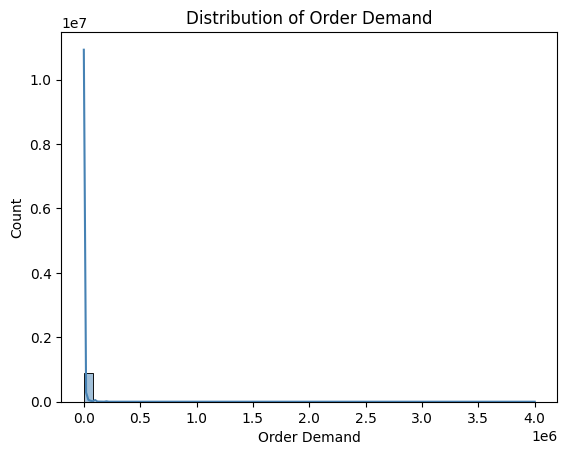

In [11]:
# Distribution of Order Demand
sns.histplot(df["Order_Demand"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Order Demand")
plt.xlabel("Order Demand")
plt.ylabel("Count")
plt.show()

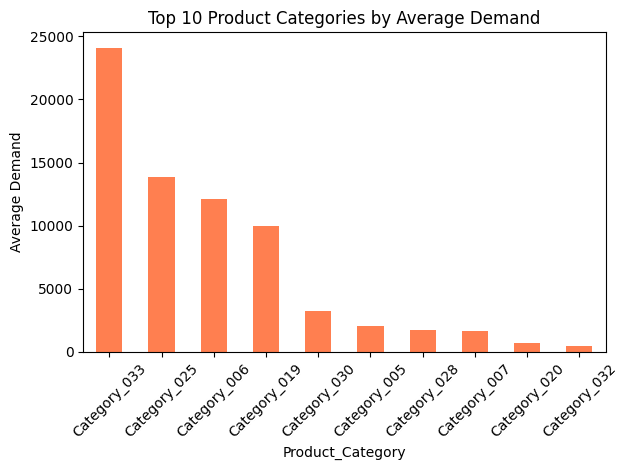

In [12]:
# Average demand per Product Category
cat_demand = df.groupby("Product_Category")["Order_Demand"].mean().sort_values(ascending=False)
cat_demand.head(10).plot(kind="bar", color="coral")
plt.title("Top 10 Product Categories by Average Demand")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cell 7 : Select X and y

In [13]:
# X = input features
# y = target (what we want to predict)

X = df[["Warehouse_Encoded", "Category_Encoded",
        "Product_Encoded", "Date_Encoded"]]
y = df["Order_Demand"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (904633, 4)
y shape: (904633,)


## Cell 8 : Log Transformation on Target
> Demand values are very large and uneven — log fixes this!

In [14]:
# np.log1p taught in M2_3 notebook by Sir!
y_log = np.log1p(y)

print("Before log — Max value:", y.max())
print("After  log — Max value:", y_log.max())

Before log — Max value: 4000000
After  log — Max value: 15.201805169084134


## Cell 9 : Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

# use y_log not y !
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 723706
Testing rows : 180927


## Cell 10 : Scaling
> StandardScaler used for Linear Regression as Sir taught

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


## Cell 11 : Model 1 — Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

# create model
linear_model = LinearRegression()

# train model
linear_model.fit(X_train_scaled, y_train)

# predict
linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression done!")

Linear Regression done!


## Cell 12 : Model 2 — Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

# create model — tuned for better R2 score
rf_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth    = 20,
    random_state = 42)

# train model — no scaling needed
rf_model.fit(X_train, y_train)

# predict
rf_pred = rf_model.predict(X_test)

print("Random Forest done!")

Random Forest done!


## Cell 13 : Model 3 — Gradient Boosting

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

# create model — tuned for better R2 score
gb_model = GradientBoostingRegressor(
    n_estimators  = 200,
    learning_rate = 0.1,
    max_depth     = 5,
    random_state  = 42)

# train model — no scaling needed
gb_model.fit(X_train, y_train)

# predict
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting done!")

Gradient Boosting done!


## Cell 14 : Evaluate — R2 Score

In [20]:
from sklearn.metrics import r2_score

# Linear Regression
linear_r2 = r2_score(y_test, linear_pred)
print("Linear Regression R2 Score :", linear_r2)

# Random Forest
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest     R2 Score :", rf_r2)

# Gradient Boosting
gb_r2 = r2_score(y_test, gb_pred)
print("Gradient Boosting R2 Score :", gb_r2)

Linear Regression R2 Score : 0.08869066247421964
Random Forest     R2 Score : 0.8160437208857071
Gradient Boosting R2 Score : 0.7854785520081646


## Cell 15 : Compare All Models

In [21]:
# compare all 3 models — same as Sir taught!
model_comp = {
    "LINEAR REGRESSION" : linear_r2,
    "RANDOM FOREST"     : rf_r2,
    "GRADIENT BOOSTING" : gb_r2
}
print(model_comp)

# find best model
best_model_name = max(model_comp, key=model_comp.get)
best_score      = model_comp[best_model_name]
print(f"Best Model : {best_model_name} with R2 Score of {best_score:.4f}")

{'LINEAR REGRESSION': 0.08869066247421964, 'RANDOM FOREST': 0.8160437208857071, 'GRADIENT BOOSTING': 0.7854785520081646}
Best Model : RANDOM FOREST with R2 Score of 0.8160


## Cell 16 : Bar Chart Comparison

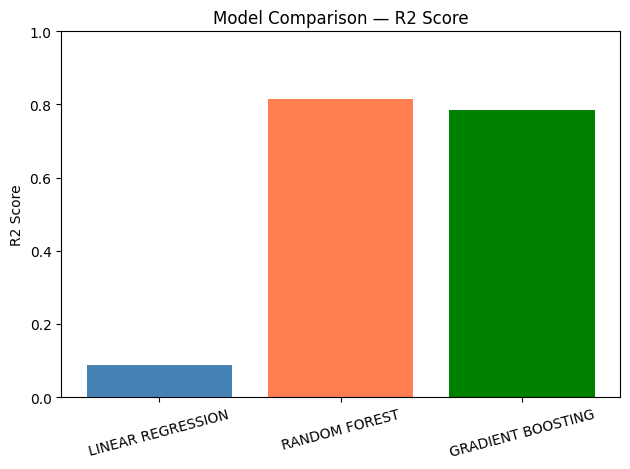

In [22]:
plt.bar(model_comp.keys(), model_comp.values(),
        color=["steelblue", "coral", "green"])
plt.title("Model Comparison — R2 Score")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Cell 17 : Save Best Model

In [23]:
import joblib

joblib.dump(rf_model, "demand_forecast_rf_model.pkl")
joblib.dump(scaler,   "scaler.pkl")

print("Best model saved as : demand_forecast_rf_model.pkl")
print("Scaler saved as     : scaler.pkl")

Best model saved as : demand_forecast_rf_model.pkl
Scaler saved as     : scaler.pkl


## Cell 18 : Predict for New Input